In [1]:
import numpy as np
from bhjet import BLJet, BHJet, TargetBlackBody
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
erg2eV = 6.242e+11 # 1erg in eV
eV2erg = 1/erg2eV
c = 3e10 # cm/s
pc = 3.086e18 # cm

First, make a new BLJet object (could be a different type of JetDynamics), all these parameters are optional and will otherwise have default values

In [3]:
bljet = BLJet(
    mass_bh=1e9, # M_sun
    jet_power_eddington=1e-5, # in units of the Eddington Luminosity
    z_jet_launching=2, # in units of rg
    r_initial=3, # in units of rg
    z_end_of_acceleration=1e5, # in units of rg
    z_dissipation=1e2, # in units of rg
    z_max_calculation=1e6, # in units of rg
    sigma_final=1,
    gamma_final=15, # Lorentz factor
    plasma_beta_jet_base=1,
    electron_temperature_jet_base=1e3, # keV
    gamma_acceleration_exponent=0.5,
    opening_angle_constant=0.15,
    fraction_nonthermal_electrons=1e-1, 
    fraction_nonthermal_protons=0.1, 
    factor_break_electrons=1, 
    factor_break_protons=1, 
    factor_max_energy_electrons=1, 
    factor_max_energy_protons=1, 
    index_injected_electrons=2, 
    index_injected_protons=2, 
    dlgz=0.1,
    verbosity_level=1
)

Next we can make the BHJet instance and assign the BLJet one to it

In [4]:
bhjet = BHJet(
    theta_obs=17, # degree
    distance=16e3, # kpc 
    redshift=0.00428,
    include_counterjet=True, 
    compton_threshold=1e-5,
    dlgp_electron = 0.05,
    dlgp_proton = 0.1,
    dlgp_cyclosyn = 0.1,
    dlgp_compton = 0.15,
    profile_time=True,
    verbosity_level=1)
bhjet.init_jet_dynamics(bljet)

We can then add edditional target fields, e.g. a black body at rest in the black hole frame. Then the jet dynamics calculation and radiation calculations for each radiation zone are carried out by compute_full_jet(). The argument specifies the energy grid [erg] on which to return the emission results.

In [5]:
bb_starlight = TargetBlackBody(
    name="starlight", 
    distance=bhjet.distance,
    redshift=bhjet.redshift,
    luminosity=1e45, # erg/(cm²s)
    temperature=1e-5, # keV
    add_to_total_flux=True,
    energy_density=1e-9) # erg/cm³

In [6]:
bhjet.clear_target_photon_fields()
bhjet.add_target_photon_field(bb_starlight)
E_out = np.logspace(-8, 19, 200)
bhjet.compute_full_jet(photon_energy_grid=E_out * eV2erg)

In [7]:
izone = -1
rad = bhjet.radiation_zones[izone]
len(rad.get_electron_momentum_grid())
rad.dlgp_proton

0.1

We can access zone i by `rad = bhjet.radiation_zones[i]`, and read out the information similar to the single_zone_example.ipynb.

Text(0.5, 1.0, 'comoving target photon spectrum, zone 25')

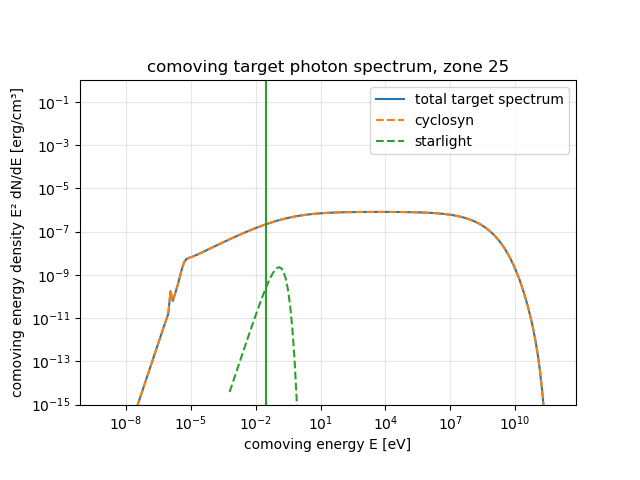

In [8]:
izone = 25
rad = bhjet.radiation_zones[izone]

fig, axpt = plt.subplots()
energy = rad.get_total_photon_target_energy()
axpt.loglog(energy*erg2eV, rad.get_total_photon_target_energy_density(), label="total target spectrum")
axpt.loglog(rad.get_photon_target_energy("cyclosynchrotron")*erg2eV, rad.get_photon_target_energy_density("cyclosynchrotron"), label="cyclosyn", ls="--")

Ebb_erg, E2dn_dE_bb = bb_starlight.get_target_energy_grid_and_density(
    z=bljet.get_z_center_grid()[izone], # does not matter for a black body
    bulk_momentum=rad.bulk_momentum, # for boosting
    theta_obs=rad.theta_obs,  # for boosting
    min_energy=1e-15, max_energy=1)  # erg, just to define the energy range
axpt.loglog(Ebb_erg * erg2eV, E2dn_dE_bb, label=bb_starlight.name, ls="--")
axpt.axvline(rad.doppler_factor_bulk * bb_starlight.temperature * 1e3, c="tab:green")

axpt.legend()
axpt.set_xlabel("comoving energy E [eV]")
axpt.set_ylabel("comoving energy density E² dN/dE [erg/cm³]")
axpt.grid(alpha=0.3)
axpt.set_aspect("equal")
axpt.set_ylim(1e-15, 1e0)
axpt.set_title(f"comoving target photon spectrum, zone {izone}")


0.005089882278526414

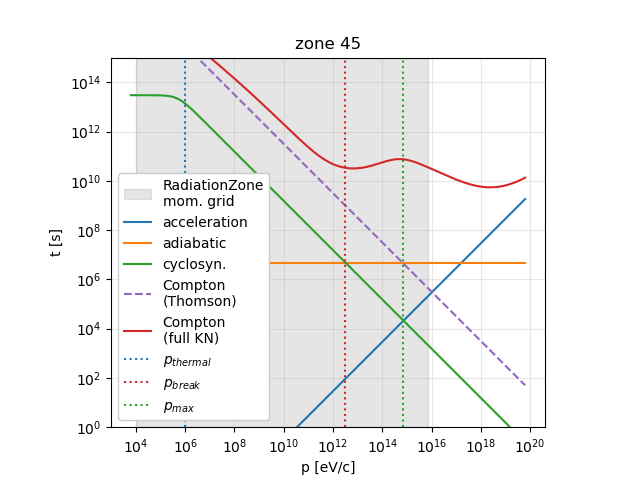

In [9]:
izone = 45
rad = bhjet.radiation_zones[izone]

fig, axt = plt.subplots()
mom = rad.get_electron_momentum_grid()
axt.axvspan(mom[0]*erg2eV*c, mom[-1]*erg2eV*c, color="grey", alpha=0.2, label="RadiationZone\nmom. grid")
mom = np.logspace(-8, 8, 160) /c
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_acceleration(mom), c="tab:blue", label="acceleration")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_adiabatic(mom), c="tab:orange", label="adiabatic")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_cyclosyn(mom), c="tab:green", label="cyclosyn.")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton_thomson(mom), c="tab:purple", label="Compton\n(Thomson)", ls="--")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton(mom), c="tab:red", label="Compton\n(full KN)")
axt.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
axt.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
axt.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
axt.legend(framealpha=1, loc="lower left")
axt.set_title(f"zone {izone}")
axt.set_xlabel("p [eV/c]")
axt.set_ylabel("t [s]")
axt.grid(alpha=0.3)
axt.set_aspect("equal")
axt.set_ylim(1, 1e15)
rad.magnetic_field

Text(0.5, 1.0, 'comoving electron spectrum')

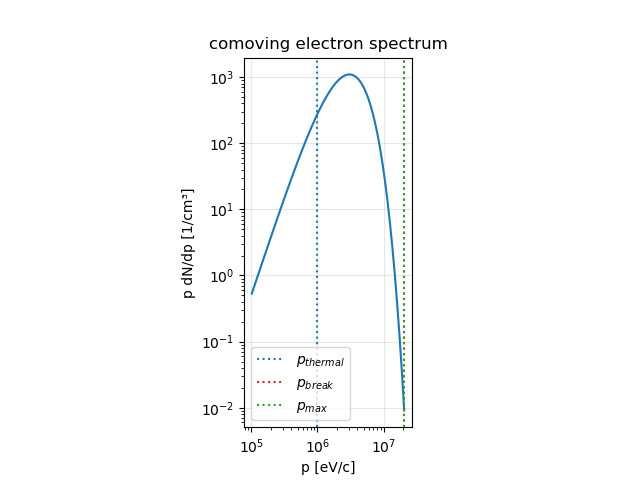

In [10]:
izone = 8
rad = bhjet.radiation_zones[izone]

fig, ax = plt.subplots()

mom = rad.get_electron_momentum_grid()
ax.loglog(mom*erg2eV*c, rad.get_electron_momentum_number_density())
ax.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
ax.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
ax.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
ax.legend()
ax.set_xlabel("p [eV/c]")
ax.set_ylabel("p dN/dp [1/cm³]")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
ax.set_title("comoving electron spectrum")


In [11]:
1/rad.get_timescale_photon_cyclosyn_selfabsorption_array()

array([2.90184437e+004, 1.82772624e+004, 1.15084237e+004, 7.24199364e+003,
       4.53658228e+003, 2.85319909e+003, 1.79098668e+003, 1.12148663e+003,
       7.00150570e+002, 4.34113961e+002, 2.68633678e+002, 1.65396574e+002,
       1.01221228e+002, 6.15022960e+001, 3.70507844e+001, 2.20960500e+001,
       1.30713597e+001, 7.59240048e+000, 4.34127880e+000, 2.43928692e+000,
       1.34449813e+000, 7.25657582e-001, 3.82744896e-001, 1.96800852e-001,
       9.84157598e-002, 4.77287262e-002, 2.23650353e-002, 1.00963696e-002,
       4.37378577e-003, 1.81079148e-003, 7.13558556e-004, 2.66030050e-004,
       9.34495643e-005, 3.07393928e-005, 9.40894315e-006, 2.66133621e-006,
       6.90324673e-007, 1.62835587e-007, 3.46071370e-008, 6.55885563e-009,
       1.09555878e-009, 1.59056878e-010, 1.97223457e-011, 2.03749054e-012,
       1.68286028e-013, 1.03441710e-014, 4.22628645e-016, 9.79358490e-018,
       1.04389112e-019, 3.90451022e-022, 3.62411662e-025, 5.35612195e-029,
       7.12496741e-034, 4

Text(0.5, 1.0, 'photons')

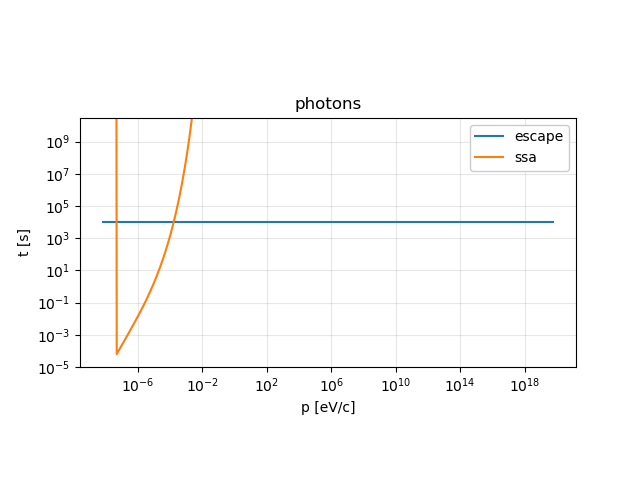

In [12]:
izone = 8
rad = bhjet.radiation_zones[izone]

fig, axt = plt.subplots()
mom = np.logspace(-20, 8, 160) /c
axt.loglog(mom*erg2eV*c, rad.get_timescale_photon_escape(mom), c="tab:blue", label="escape")
axt.loglog(mom*erg2eV*c, rad.get_timescale_photon_cyclosyn_selfabsorption(mom), c="tab:orange", label="ssa")

axt.legend(framealpha=1)
axt.set_xlabel("p [eV/c]")
axt.set_ylabel("t [s]")
axt.grid(alpha=0.3)
axt.set_aspect("equal")
axt.set_ylim(1e-5, 3e10)
axt.set_title("photons")

(1e-25, 1e-10)

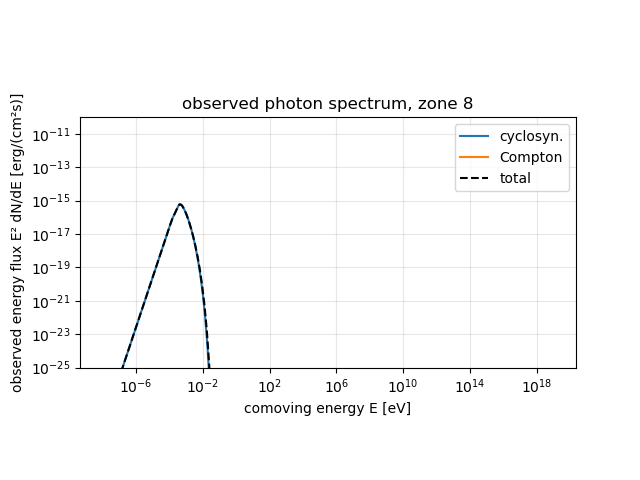

In [13]:
izone = 8
rad = bhjet.radiation_zones[izone]

fig, axp = plt.subplots()

energy_syn = rad.get_observed_photon_energy_grid_electron_cyclosyn()
axp.loglog(energy_syn*erg2eV,energy_syn * rad.get_observed_photon_flux_electron_cyclosyn(), label="cyclosyn.")
energy_com = rad.get_observed_photon_energy_grid_electron_compton()
axp.loglog(energy_com*erg2eV,energy_com * rad.get_observed_photon_flux_electron_compton(), label="Compton")
energy_tot = rad.get_observed_photon_energy_grid_total()
axp.loglog(energy_tot*erg2eV,energy_tot * rad.get_observed_photon_flux_total(), label="total", c="k", ls="--")

# print(energy_com * rad.get_observed_photon_flux_electron_compton())
axp.legend()
axp.set_xlabel("comoving energy E [eV]")
axp.set_ylabel("observed energy flux E² dN/dE [erg/(cm²s)]")
axp.grid(alpha=0.3)
axp.set_aspect("equal")
axp.set_title(f"observed photon spectrum, zone {izone}")
axp.set_ylim(1e-25, 1e-10)


It can also be useful to read out the characteristic momenta for the photons as a function of distance along the jet, to see how the spectral shapes evolve.

Text(0, 0.5, 'characteristic electron energy [eV]')

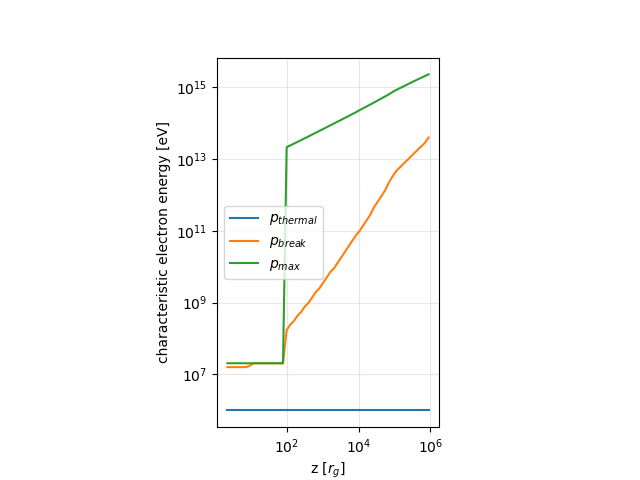

In [14]:
fig, ax = plt.subplots()
p_ths, p_brs, p_maxs = [], [], []
for i in range(bljet.n_zones):
    p_ths.append(bhjet.radiation_zones[i].electron_temperature * 1e3)
    p_brs.append(bhjet.radiation_zones[i].get_electron_break_momentum()*erg2eV*c)
    p_maxs.append(bhjet.radiation_zones[i].get_electron_max_momentum()*erg2eV*c)
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_ths, label=r"$p_{thermal}$")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_brs, label=r"$p_{break}$")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_maxs, label=r"$p_{max}$")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"characteristic electron energy [eV]")

Next we read out the total emission and the contributions from different jet segments.

In [15]:
bhjet.get_observed_photon_flux_total()

array([0.00000000e+000, 5.50965560e-001, 6.28690545e-001, 6.92635945e-001,
       7.50792795e-001, 8.10342993e-001, 8.82472872e-001, 9.82974310e-001,
       1.12505151e+000, 1.31995900e+000, 1.57885059e+000, 1.91222929e+000,
       2.33065239e+000, 2.85598346e+000, 3.51068021e+000, 4.32028905e+000,
       5.28362725e+000, 6.46097699e+000, 7.94416362e+000, 9.77529614e+000,
       1.16220967e+001, 1.38380062e+001, 1.63962920e+001, 1.97233660e+001,
       2.30954223e+001, 2.68134130e+001, 3.09809782e+001, 3.58369207e+001,
       4.25331851e+001, 5.30400347e+001, 7.20218498e+001, 1.07780897e+002,
       1.75129057e+002, 3.01854495e+002, 5.38414673e+002, 9.78020942e+002,
       1.79134822e+003, 3.28752329e+003, 6.01397013e+003, 1.09243632e+004,
       1.96481449e+004, 3.48514809e+004, 6.05650727e+004, 1.02246072e+005,
       1.66041238e+005, 2.53398309e+005, 3.54415410e+005, 4.34346047e+005,
       4.37297163e+005, 3.25844229e+005, 1.63298457e+005, 4.58452246e+004,
       6.75017854e+003, 4

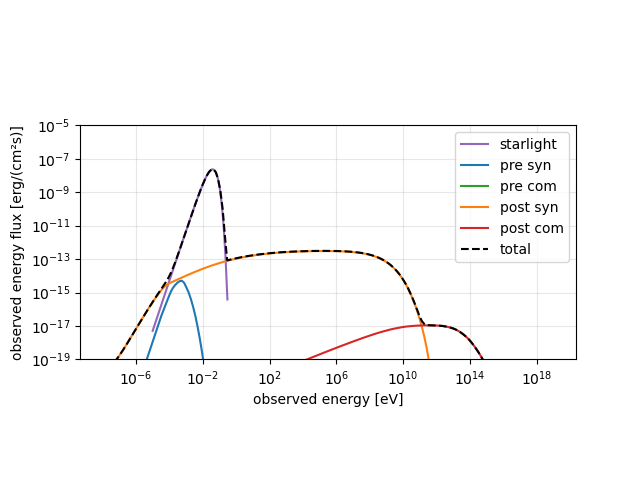

In [16]:
fig, ax = plt.subplots()
# bhjet.set_target_black_body_luminosity("starlight", 1e45)


ax.loglog(bb_starlight.get_observed_energy()*erg2eV, bb_starlight.get_observed_energy_flux(), label=bb_starlight.name, color="tab:purple")
# Ebb = bhjet.get_observed_photon_energy_grid_black_body("starlight")
# ax.loglog(Ebb*erg2eV, Ebb*bhjet.get_observed_photon_flux_black_body("starlight"), c="tab:purple", label="starlight")

ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, bljet.z_dissipation*bljet.r_g), c="tab:blue", label="pre syn")
ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, bljet.z_dissipation*bljet.r_g), c="tab:green", label="pre com")
ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    bljet.z_dissipation*bljet.r_g, bljet.z_max_calculation*bljet.r_g), c="tab:orange", label="post syn")
ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    bljet.z_dissipation*bljet.r_g, bljet.z_max_calculation*bljet.r_g), c="tab:red", label="post com")

ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_flux_total(), c="k", label="total", ls="--")

ax.legend()
ax.set_xlabel(r"observed energy [eV]")
ax.set_ylabel(r"observed energy flux [erg/(cm²s)]")
ax.set_ylim(1e-19, 1e-5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

We can also check the computation time per zone and for the jet dynamics (first element). One can clearly see, how the Compton calculation is the slowest part of the computation.

(0.001, 10000.0)

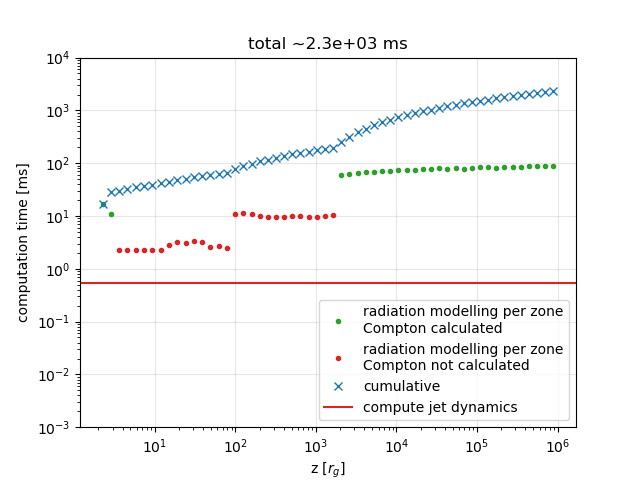

In [17]:
fig, ax = plt.subplots()
mask = np.array([bhjet.radiation_zones[i].compton_calculation_necessary() for i in range(bljet.n_zones)])

ax.loglog(bljet.get_z_center_grid()[mask]/bljet.r_g, 1e-6* bhjet.get_computation_times()[1:][mask],
          ls="", marker=".", label="radiation modelling per zone\nCompton calculated", color='tab:green')
ax.loglog(bljet.get_z_center_grid()[~mask]/bljet.r_g, 1e-6* bhjet.get_computation_times()[1:][~mask],
          ls="", marker=".", label="radiation modelling per zone\nCompton not calculated", color='tab:red')
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, 1e-6* np.cumsum(bhjet.get_computation_times()[1:]),
          ls="", marker="x", label="cumulative")
ax.axhline(1e-6* bhjet.get_computation_times()[0], color="tab:red", label="compute jet dynamics")
ax.set_title(f"total ~{1e-6*np.sum(bhjet.get_computation_times()):.1e} ms")
ax.legend(loc="lower right")
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"computation time [ms]")
ax.grid(alpha=0.3)
ax.set_ylim(1e-3, 1e4)